In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.array([5,2,6,1])
y = np.array([2,1,6,2])
# mean x ->
mean_x = sum(val for val in x) / len(x)
mean_y = sum(val for val in y) / len(y)
print("Means: ", mean_x, mean_y)

# variance 11 22
var11 = sum((xi - mean_x)**2 for xi in x) / (len(x) - 1)
var22 = sum((yi - mean_y)**2 for yi in y) / (len(y) - 1)
print("Variances 11 22: ", var11, var22)

# variance 12
var12 = 0
for i in range(len(x)):
    var12 += (x[i] - mean_x) * (y[i] - mean_y)
var12 = var12 / (len(x) - 1)
var21 = var12
print("var12:", var12)

# Eigen calculation
cov_mat = np.array([var11, var12, var21, var22]).reshape(2,2)
print("cov_mat", cov_mat)
eigval, eigvec = np.linalg.eig(cov_mat)
print("Eigen Values: ", eigval)
print("Eigen Vectors: ", eigvec)
print("Norm: ", np.linalg.norm(eigvec))
data = np.vstack((x, y))
pca = eigvec.T @ (data - data.mean(axis=1, keepdims=True))
print("pca: ", pca)


Means:  3.5 2.75
Variances 11 22:  5.666666666666667 4.916666666666667
var12: 3.8333333333333335
cov_mat [[5.66666667 3.83333333]
 [3.83333333 4.91666667]]
Eigen Values:  [9.14329872 1.44003462]
Eigen Vectors:  [[ 0.74072982 -0.67180305]
 [ 0.67180305  0.74072982]]
Norm:  1.4142135623730951
pca:  [[ 0.60724244 -2.28675006  4.03518445 -2.35567683]
 [-1.56325194 -0.28857261  0.72786428  1.12396026]]


data.feature_names ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
pca_captured [0.72962445 0.22850762]
cumulative_variance 0.9581320720000166


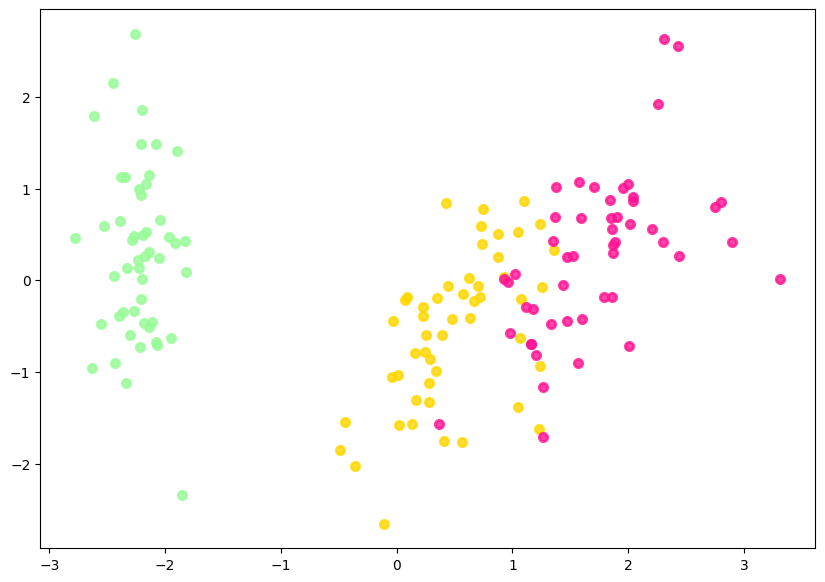

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
# print("Original iris: ", iris)
print("data.feature_names", iris.feature_names)
# print("data.data_module", iris.cumulative_variance = np.sum(explained_variance))
# data without headings
# print("iris: ", iris.data)
x = iris.data
y = iris.target
# print("x", x)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
# print("X_scaled", x_scaled)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
# print("x_pca", x_pca)

pca_captured = pca.explained_variance_ratio_
print("pca_captured", pca_captured)
cumulative_variance = np.sum(pca_captured)
print("cumulative_variance", cumulative_variance)

plt.figure(figsize=(10, 7))
colors = ['palegreen', 'gold', 'deeppink']

for color, i, target_name in zip(colors, [0, 1, 2], iris.feature_names):
  plt.scatter(x_pca[y == i, 0], x_pca[y == i, 1], color=color, alpha=0.8, lw=2,label=target_name)

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:598: UserWarning: n_components is too large: it will be set to 2
  warnings.warn(


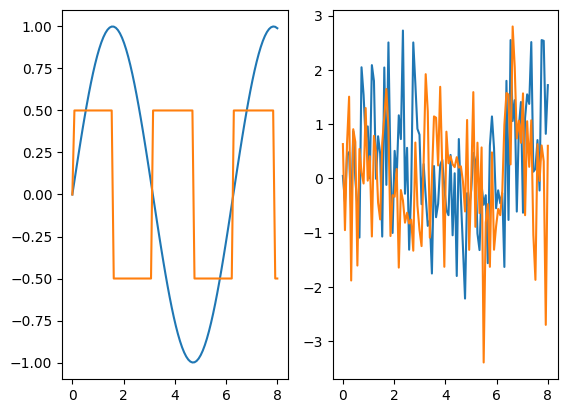

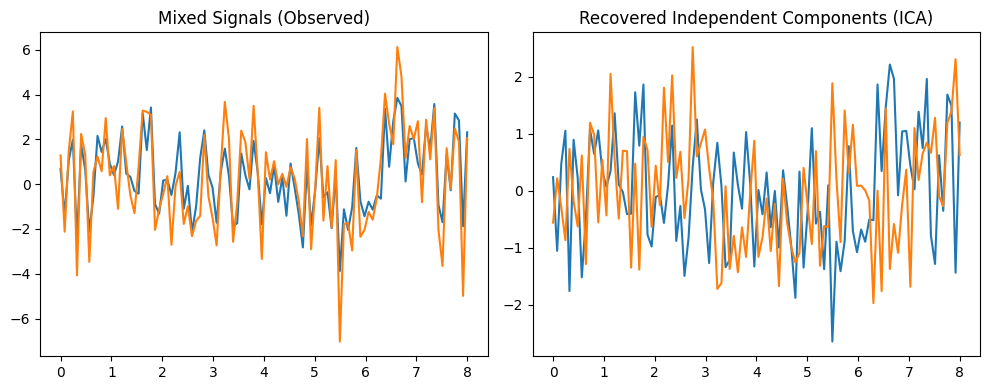

Estimated Mixing Matrix:
 [[ 1.63522488  0.06323663]
 [ 2.03959905 -0.99860278]]


In [ ]:
from sklearn.decomposition import FastICA

t = np.linspace(0,8,100)
sig1 = np.sin(t)
plt.subplot(1,2,1)
plt.plot(t,sig1)
sig2 = 0.5 * np.sign(np.sin(2 * t))
plt.plot(t,sig2)

sigs = np.c_[sig1,sig2]
noise = np.random.normal(size=sigs.shape)
noise_s = sigs+noise
plt.subplot(1,2,2)
plt.plot(t,noise_s)

mixing_matrix = np.array([[1, 1], [0.5, 2]])
X = noise_s.dot(mixing_matrix.T)
ica = FastICA(n_components=2,random_state=0)
S_ = ica.fit_transform(X)
A_ = ica.mixing_

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, X)
plt.title("Mixed Signals (Observed)")
plt.subplot(1, 2, 2)
plt.plot(t, S_)
plt.title("Recovered Independent Components (ICA)")
plt.tight_layout()
plt.show()

print("Estimated Mixing Matrix:\n", A_)

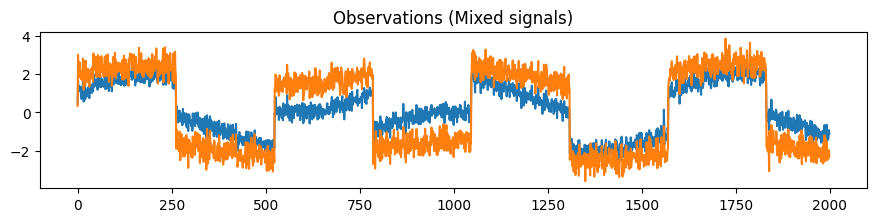

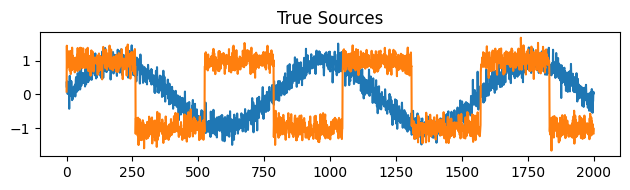

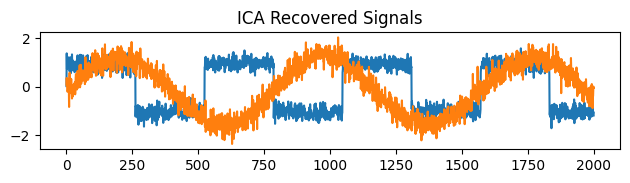

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
# Generate synthetic signals (2 sources)
np.random.seed(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)
s1 = np.sin(2 * time)  # Sinusoidal signal
s2 = np.sign(np.sin(3 * time))  # Square signal
S = np.c_[s1, s2]
S += 0.2 * np.random.normal(size=S.shape)  # Add noise
# Mix signals
A = np.array([[1, 1], [0.5, 2]])  # Mixing matrix
X = S.dot(A.T)
# Apply ICA
ica = FastICA(n_components=2, random_state=0)
S_ = ica.fit_transform(X)
A_ = ica.mixing_
# Plot results
plt.figure(figsize=(9,6))
models = [X, S, S_]
names = ['Observations (Mixed signals)', 'True Sources',
'ICA Recovered Signals']
for ii, (model, name) in enumerate(zip(models, names), 1):
  plt.subplot(3, 1, ii)
  plt.title(name)
  plt.plot(model)
  plt.tight_layout()
  plt.show()